In [ ]:
# mount the drive
from google.colab import drive
drive.mount("/content/drive")

ROOT_DIR = "/content/drive/MyDrive/colab/test"

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ── pip install lightgbm scikit-learn matplotlib ──────────────────────────────
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import LabelEncoder

# =============================================================================
# 1. LOAD DATA
# =============================================================================
df = pd.read_csv(f"{ROOT_DIR}/covid_dataset2.csv", parse_dates=["date"])
df = df.sort_values(["country_region", "date"]).reset_index(drop=True)


print(f"Loaded: {df.shape[0]:,} rows | {df['country_region'].nunique()} countries")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")

Loaded: 120,297 rows | 124 countries
Date range: 2020-02-15 → 2022-10-15


In [8]:
# =============================================================================
# 2. HANDLE MISSING VALUES
# =============================================================================
MOBILITY_COLS = [
    "retail_and_recreation_percent_change_from_baseline",
    "grocery_and_pharmacy_percent_change_from_baseline",
    "parks_percent_change_from_baseline",
    "transit_stations_percent_change_from_baseline",
    "workplaces_percent_change_from_baseline",
    "residential_percent_change_from_baseline",
]

# Forward-fill then backward-fill within each country (safe for mobility data)
df[MOBILITY_COLS] = (
    df.groupby("country_region")[MOBILITY_COLS]
    .transform(lambda x: x.ffill().bfill())
)

print(f"Missing after imputation: {df[MOBILITY_COLS].isnull().sum().sum()}")

# =============================================================================
# 3. CREATE TARGET — DAILY NEW CASES (not cumulative!)
# =============================================================================
df["daily_new"] = (
    df.groupby("country_region")["confirmed_cases"]
    .diff()
    .clip(lower=0)       # corrections in data can produce negatives
)

# Drop the first row per country (NaN diff)
df = df.dropna(subset=["daily_new"]).reset_index(drop=True)

# Log-transform to handle extreme skewness (skew = 6.0 in raw data)
df["target"] = np.log1p(df["daily_new"])

Missing after imputation: 3694


In [9]:
# =============================================================================
# 4. FEATURE ENGINEERING
# =============================================================================
def make_features(df: pd.DataFrame) -> pd.DataFrame:
    g = df.groupby("country_region")

    # ── Lag features (previous day counts carry the most signal) ─────────────
    for lag in [1, 3, 7, 14, 21]:
        df[f"lag_{lag}"] = g["daily_new"].shift(lag)

    # ── Rolling statistics (smooth weekend reporting dips) ────────────────────
    for window in [7, 14]:
        df[f"roll_mean_{window}"] = (
            g["daily_new"].shift(1)
            .transform(lambda x: x.rolling(window, min_periods=1).mean())
        )
        df[f"roll_std_{window}"] = (
            g["daily_new"].shift(1)
            .transform(lambda x: x.rolling(window, min_periods=1).std().fillna(0))
        )

    # ── Growth rate (is the wave accelerating?) ───────────────────────────────
    df["growth_rate_7d"] = (
        df["daily_new"] / (g["daily_new"].shift(7) + 1)
    ).clip(0, 20)  # clip outlier ratios

    # ── Mobility lags (mobility leads cases by ~7-14 days) ────────────────────
    for col in MOBILITY_COLS:
        short = col.split("_percent")[0]
        df[f"{short}_lag7"] = g[col].shift(7)
        df[f"{short}_roll7"] = (
            g[col].shift(1).transform(lambda x: x.rolling(7, min_periods=1).mean())
        )

    # ── Calendar features (captures weekend/holiday reporting patterns) ────────
    df["day_of_week"]   = df["date"].dt.dayofweek      # 0=Mon, 6=Sun
    df["month"]         = df["date"].dt.month
    df["week_of_year"]  = df["date"].dt.isocalendar().week.astype(int)
    df["is_weekend"]    = (df["day_of_week"] >= 5).astype(int)

    # ── Days since outbreak per country ──────────────────────────────────────
    first_case = df[df["daily_new"] > 0].groupby("country_region")["date"].min()
    df["days_since_outbreak"] = (
        df["date"] - df["country_region"].map(first_case)
    ).dt.days.clip(lower=0)

    # ── Country encoding (label encode — avoids 124-column one-hot) ──────────
    le = LabelEncoder()
    df["country_enc"] = le.fit_transform(df["country_region"])

    return df

df = make_features(df)

In [12]:
# =============================================================================
# 5. DEFINE FEATURES & TARGET
# =============================================================================
lag_cols      = [c for c in df.columns if c.startswith("lag_")]
roll_cols     = [c for c in df.columns if c.startswith("roll_")]
mob_lag_cols  = [c for c in df.columns if c.endswith("_lag7") or c.endswith("_roll7")]
calendar_cols = ["day_of_week", "month", "week_of_year", "is_weekend"]
other_cols    = ["country_enc", "days_since_outbreak", "growth_rate_7d"]

FEATURE_COLS = lag_cols + roll_cols + mob_lag_cols + calendar_cols + other_cols
TARGET_COL   = "target"  # log1p(daily_new)

print(f"\nTotal features: {len(FEATURE_COLS)}")
print(f"Feature groups: {len(lag_cols)} lags | {len(roll_cols)} rolling | "
      f"{len(mob_lag_cols)} mobility | {len(calendar_cols)} calendar | {len(other_cols)} other")

# Drop rows where lag features are NaN (first ~21 days per country)
df_model = df.dropna(subset=FEATURE_COLS).copy()
print(f"Rows available for modelling: {len(df_model):,}")

# =============================================================================
# 6. TRAIN / TEST SPLIT — by date (NEVER random for time series!)
# =============================================================================
CUTOFF = df_model["date"].max() - pd.Timedelta(days=60)

train = df_model[df_model["date"] <= CUTOFF]
test  = df_model[df_model["date"] >  CUTOFF]

X_train, y_train = train[FEATURE_COLS], train[TARGET_COL]
X_test,  y_test  = test[FEATURE_COLS],  test[TARGET_COL]

print(f"\nTrain: {len(train):,} rows (up to {CUTOFF.date()})")
print(f"Test : {len(test):,} rows  (last 60 days)")

# =============================================================================
# 7. TIME-SERIES CROSS-VALIDATION (on training data)
# =============================================================================
tscv = TimeSeriesSplit(n_splits=5)
cv_rmse = []

lgb_params = dict(
    objective        = "regression",
    metric           = "rmse",
    num_leaves       = 127,
    learning_rate    = 0.05,
    feature_fraction = 0.8,
    bagging_fraction = 0.8,
    bagging_freq     = 5,
    min_child_samples= 20,
    n_estimators     = 500,
    early_stopping_rounds = 30,
    verbose          = -1,
)

print("\nRunning 5-fold time-series CV ...")
for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train), 1):
    Xtr, Xval = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    ytr, yval = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    m = lgb.LGBMRegressor(**lgb_params)
    m.fit(Xtr, ytr, eval_set=[(Xval, yval)])

    pred_log  = m.predict(Xval)
    pred_real = np.expm1(pred_log)
    true_real = np.expm1(yval)

    rmse = np.sqrt(mean_squared_error(true_real, pred_real))
    cv_rmse.append(rmse)
    print(f"  Fold {fold}: RMSE = {rmse:,.0f} new cases/day")

print(f"  Mean CV RMSE: {np.mean(cv_rmse):,.0f} ± {np.std(cv_rmse):,.0f}")

# =============================================================================
# 8. FINAL MODEL TRAINING
# =============================================================================
print("\nTraining final model on all training data ...")

final_params = {k: v for k, v in lgb_params.items()
                if k != "early_stopping_rounds"}
final_params["n_estimators"] = 700  # slightly more without early stopping

model = lgb.LGBMRegressor(**final_params)
model.fit(X_train, y_train)

# =============================================================================
# 9. EVALUATE ON HELD-OUT TEST SET
# =============================================================================
y_pred_log  = model.predict(X_test)
y_pred_real = np.expm1(y_pred_log)
y_true_real = np.expm1(y_test)

mae  = mean_absolute_error(y_true_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_true_real, y_pred_real))
# MAPE: skip near-zero true values to avoid division instability
mask = y_true_real > 10
mape = (np.abs(y_true_real[mask] - y_pred_real[mask]) / y_true_real[mask]).mean() * 100

print(f"\n{'='*40}")
print(f"TEST SET RESULTS (last 60 days)")
print(f"  MAE  : {mae:>12,.0f}  new cases/day")
print(f"  RMSE : {rmse:>12,.0f}  new cases/day")
print(f"  MAPE : {mape:>11.1f}%")
print(f"{'='*40}")

# =============================================================================
# 10. FEATURE IMPORTANCE
# =============================================================================
importance = pd.DataFrame({
    "feature"   : FEATURE_COLS,
    "importance": model.feature_importances_,
}).sort_values("importance", ascending=False)

print("\nTop 15 features:")
print(importance.head(15).to_string(index=False))


Total features: 28
Feature groups: 5 lags | 4 rolling | 12 mobility | 4 calendar | 3 other
Rows available for modelling: 115,766

Train: 108,506 rows (up to 2022-08-16)
Test : 7,260 rows  (last 60 days)

Running 5-fold time-series CV ...
  Fold 1: RMSE = 10,776 new cases/day
  Fold 2: RMSE = 6,821 new cases/day
  Fold 3: RMSE = 1,866 new cases/day
  Fold 4: RMSE = 1,048 new cases/day
  Fold 5: RMSE = 9,066 new cases/day
  Mean CV RMSE: 5,915 ± 3,859

Training final model on all training data ...

TEST SET RESULTS (last 60 days)
  MAE  :          283  new cases/day
  RMSE :        1,966  new cases/day
  MAPE :        20.1%

Top 15 features:
               feature  importance
                 lag_7        9295
        growth_rate_7d        9241
           roll_mean_7        6839
                 lag_1        5408
          roll_mean_14        4921
                lag_14        4270
            roll_std_7        3990
           roll_std_14        3969
                lag_21        3115
 


Plot saved → covid_predictions.png

14-day autoregressive forecast for India:
      date  predicted_new_cases
2022-10-02                 2407
2022-10-03                 2369
2022-10-04                 2733
2022-10-05                 2787
2022-10-06                 2830
2022-10-07                 2913
2022-10-08                 2997
2022-10-09                 3030
2022-10-10                 3034
2022-10-11                 3095
2022-10-12                 3110
2022-10-13                 3166
2022-10-14                 3136
2022-10-15                 3147


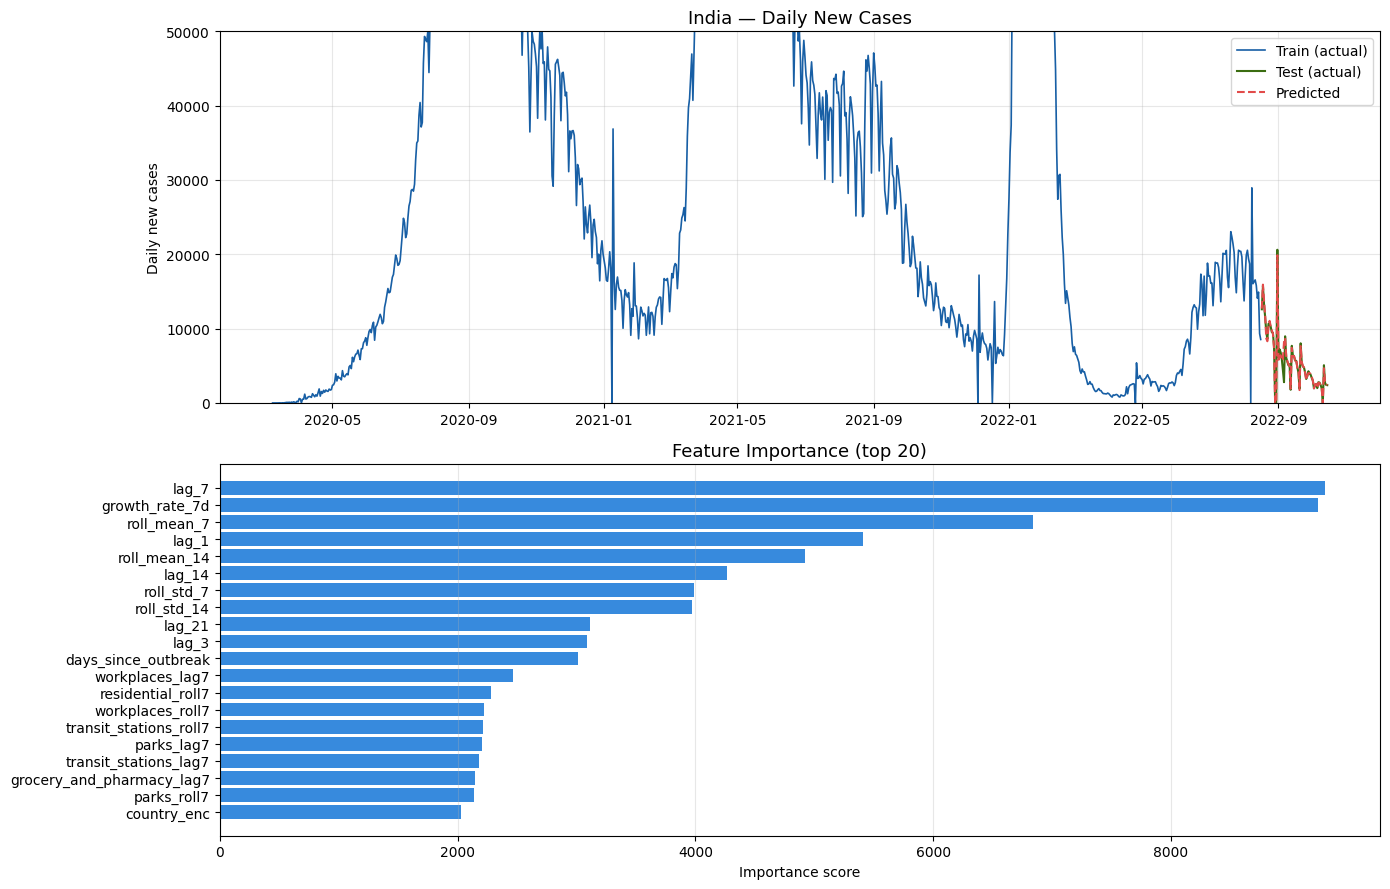

In [ ]:
# =============================================================================
# 11. PLOT: PREDICTIONS vs ACTUALS FOR A SINGLE COUNTRY
# =============================================================================
PLOT_COUNTRY = "india"   # change to any country in the dataset

country_test = test[test["country_region"] == PLOT_COUNTRY].copy()
country_test["pred"] = np.expm1(model.predict(country_test[FEATURE_COLS]))
country_train = train[train["country_region"] == PLOT_COUNTRY].copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# ── Top: full history + prediction overlay ────────────────────────────────────
ax = axes[0]
ax.plot(country_train["date"], country_train["daily_new"],
        color="#185FA5", lw=1.2, label="Train (actual)")
ax.plot(country_test["date"], country_test["daily_new"],
        color="#3B6D11", lw=1.5, label="Test (actual)")
ax.plot(country_test["date"], country_test["pred"],
        color="#E24B4A", lw=1.5, linestyle="--", label="Predicted")
ax.set_title(f"{PLOT_COUNTRY.title()} — Daily New Cases", fontsize=13)
ax.set_ylabel("Daily new cases")
ax.set_ylim(0, 50000)
ax.legend()
ax.grid(True, alpha=0.3)

# ── Bottom: feature importance (top 20) ───────────────────────────────────────
ax2 = axes[1]
top20 = importance.head(20)
ax2.barh(top20["feature"][::-1], top20["importance"][::-1], color="#378ADD")
ax2.set_title("Feature Importance (top 20)", fontsize=13)
ax2.set_xlabel("Importance score")
ax2.grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("covid_predictions.png", dpi=150, bbox_inches="tight")
print(f"\nPlot saved → covid_predictions.png")

# =============================================================================
# 12. PREDICT NEXT N DAYS (AUTOREGRESSIVE FORECAST)
# =============================================================================
def forecast_next_n(country: str, n_days: int = 14) -> pd.DataFrame:
    """
    Walk-forward forecast for a single country.
    Each step uses the previous step's prediction as the lag feature.
    """
    history = df_model[df_model["country_region"] == country].copy()
    last_date = history["date"].max() - pd.Timedelta(days=14)
    preds = []

    for i in range(1, n_days + 1):
        next_date = last_date + pd.Timedelta(days=i)
        row = {}
        row["country_enc"]         = history["country_enc"].iloc[-1]
        row["days_since_outbreak"] = history["days_since_outbreak"].iloc[-1] + i
        row["day_of_week"]         = next_date.dayofweek
        row["month"]               = next_date.month
        row["week_of_year"]        = next_date.isocalendar().week
        row["is_weekend"]          = int(next_date.dayofweek >= 5)

        for lag in [1, 3, 7, 14, 21]:
            row[f"lag_{lag}"] = history["daily_new"].iloc[-lag] if len(history) >= lag else 0

        for window in [7, 14]:
            recent = history["daily_new"].iloc[-window:].values
            row[f"roll_mean_{window}"] = np.mean(recent)
            row[f"roll_std_{window}"]  = np.std(recent) if len(recent) > 1 else 0

        row["growth_rate_7d"] = min(
            history["daily_new"].iloc[-1] / (history["daily_new"].iloc[-7] + 1), 20
        )

        for col in MOBILITY_COLS:
            short = col.split("_percent")[0]
            row[f"{short}_lag7"]  = history[col].iloc[-7] if len(history) >= 7 else 0
            row[f"{short}_roll7"] = history[col].iloc[-7:].mean()

        X_row  = pd.DataFrame([row])[FEATURE_COLS]
        pred   = float(np.expm1(model.predict(X_row)[0]))
        preds.append({"date": next_date, "predicted_new_cases": round(pred)})

        # Append prediction to history so next step's lags are correct
        new_row = history.iloc[[-1]].copy()
        new_row["date"]      = next_date
        new_row["daily_new"] = pred
        history = pd.concat([history, new_row], ignore_index=True)

    return pd.DataFrame(preds)

print(f"\n14-day autoregressive forecast for {PLOT_COUNTRY.title()}:")
forecast_df = forecast_next_n(PLOT_COUNTRY, n_days=14)
print(forecast_df.to_string(index=False))